# Effective Potential of a Real Scalar Field Theory

This notebook is used to compute the plots for the Master Thesis but also it serves as a ligh validity test for all that it is to come. For the rest of the models, we use $\texttt{CosmoTransitions}$ for the numerical handling of the effective potential. Since we are not going to do any thermal field theory on this model, the full analysis will be keep in this notebook.

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

In [2]:
def get_params(m,u):
    l  = 3*m**2/u**2
    mu2 = u**2*l/6

    return mu2, l

def V0(x,params):
    mu2, l = params
    return -0.5*mu2*x**2 + l/(24)*x**4

def M2(x, params):
    mu2, l = params
    return -mu2 + 0.5*l*x**2

def VCW(x, params, Q):
    x = np.asarray(x, dtype=float)
    m2 = M2(x, params)
    mask = m2 > 0

    safe_m2 = np.where(mask, m2, 1.0)   # dummy value
    vcw = m2**2 / (64*np.pi**2) * (-3/2 + np.log(safe_m2 / Q**2))

    return np.where(mask, vcw, 0)
    
def cw_derivs(u, params, Q, h=None):
    if h is None:
        h = 1e-4 * abs(u)

    f0  = VCW(u,     params, Q)
    fp1 = VCW(u + h, params, Q)
    fm1 = VCW(u - h, params, Q)

    Vu   = float(f0)
    Vux  = float((fp1 - fm1) / (2*h))
    Vuxx = float((fp1 - 2*f0 + fm1) / h**2)
    return Vu, Vux, Vuxx

def get_CT_params(u, params, Q, h=None):
    Vu, Vux, Vuxx = cw_derivs(u, params, Q, h)

    a = -((-3*Vux + u*Vuxx) / (2*u))
    b = -((3*(-Vux + u*Vuxx)) / u**3)
    c = 0.125 * (-8*Vu + 5*u*Vux - u**2*Vuxx)
    return a, b, c


def VCT(x, ct_params):
    a, b, c = ct_params
    return -a/2*x**2 + b/24*x**4 + c

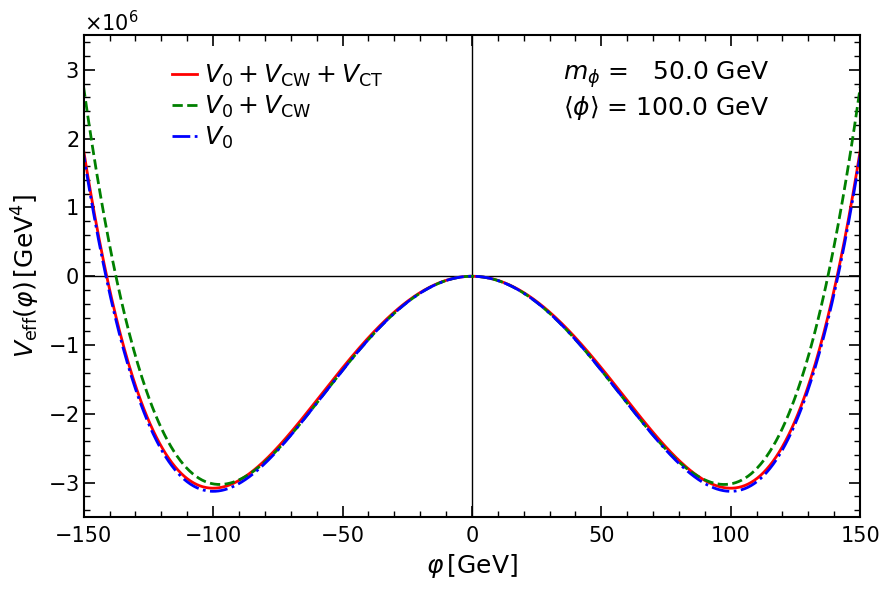

In [34]:
m = 50  # GeV
u = 100 # Gev
x = np.linspace(-200,200,1000)

mu2, l = get_params(m,u)
VTL = V0(x,[mu2,l])
VTL0 = V0(0,[mu2,l])
V1  = VCW(x, [mu2,l], 0.1)
V10  = VCW(0, [mu2,l], 0.1)
a,b,c = get_CT_params(u, [mu2, l], 0.1, 1e-6*u)
Vct = VCT(x, [a,b,c])
Vct0 = VCT(0, [a,b,c])

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(x, VTL+V1+Vct-VTL0-V10-Vct0, label=r'$V_0+V_\mathrm{CW}+V_{\mathrm{CT}}$', color='r', lw=2, ls='-')
ax.plot(x, VTL+V1-VTL0-V10, label=r'$V_0+V_{\mathrm{CW}}$', color='g', lw=2, ls='--')
ax.plot(x, VTL-VTL0, label=r'$V_0$', color='b', lw=2, ls='-.')

ax.set_xlim(-150, 150)
ax.set_ylim(-3.5e6, 3.5e6)

ax.set_xlabel(r'$\varphi \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper center", bbox_to_anchor=(0.25, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = rf'$m_\phi$ =   {m:.1f} GeV' '\n' rf'$\langle\phi\rangle$ = {u:.1f} GeV'
ax.text(0.75, 0.95, annotation, transform=ax.transAxes, fontsize=18,
        verticalalignment='top', horizontalalignment='center',
        bbox=dict(facecolor='white', edgecolor='black', alpha=0))

plt.tight_layout()
plt.savefig(f"RSF_Veff.pdf", format="pdf", bbox_inches="tight")
plt.show()

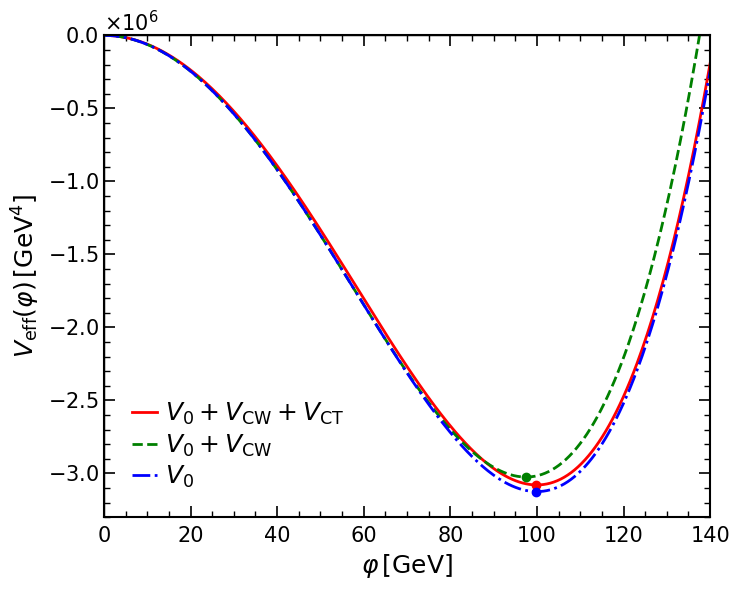

In [33]:
m = 50  # GeV
u = 100 # Gev
x = np.linspace(-200,200,1000)

mu2, l = get_params(m,u)
VTL = V0(x,[mu2,l])
VTL0 = V0(0,[mu2,l])
V1  = VCW(x, [mu2,l], 0.1)
V10  = VCW(0, [mu2,l], 0.1)
a,b,c = get_CT_params(u, [mu2, l], 0.1, 1e-6*u)
Vct = VCT(x, [a,b,c])
Vct0 = VCT(0, [a,b,c])

fig, ax = plt.subplots(figsize=(7.5, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(x, VTL+V1+Vct-VTL0-V10-Vct0, label=r'$V_0+V_\mathrm{CW}+V_{\mathrm{CT}}$', color='r', lw=2, ls='-')
ax.plot(x, VTL+V1-VTL0-V10, label=r'$V_0+V_{\mathrm{CW}}$', color='g', lw=2, ls='--')
ax.plot(x, VTL-VTL0, label=r'$V_0$', color='b', lw=2, ls='-.')

r = np.array(VTL+V1+Vct-VTL0-V10-Vct0)
g = np.array(VTL+V1-VTL0-V10)
b = np.array(VTL-VTL0)
colors = ['r', 'g', 'b']
mask = (x>0)

for i, ar in enumerate([r, g, b]):
    ar_masked = ar[mask]
    x_masked = x[mask]
    id = np.argmin(ar_masked)
    ax.plot(x_masked[id], ar_masked[id], marker='o', color=colors[i], ms=6)

ax.set_xlim(0, 140)
ax.set_ylim(-3.3e6, 0)

ax.set_xlabel(r'$\varphi \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"RSF_Veff_Zoom.pdf", format="pdf", bbox_inches="tight")
plt.show()

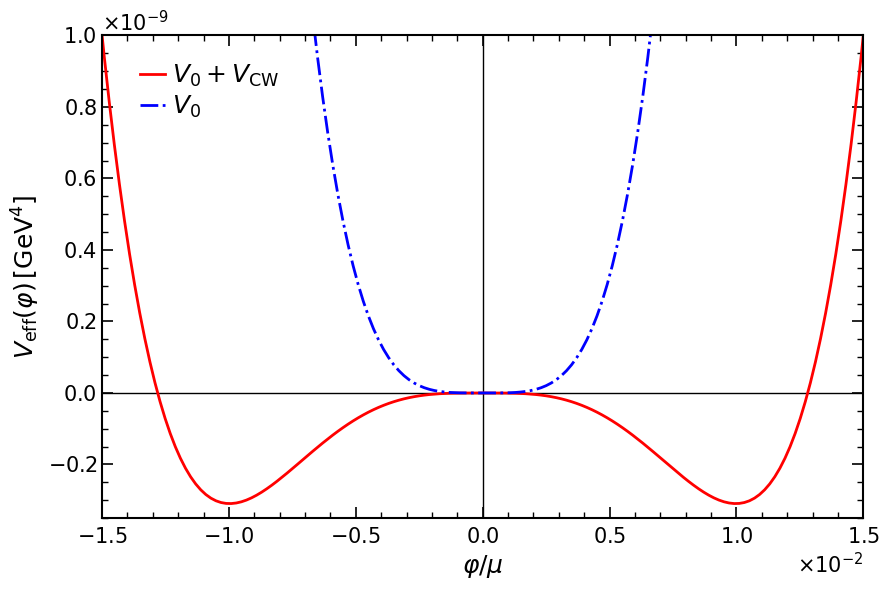

In [87]:
l = 4*np.pi
Q = 1
x = np.linspace(-0.1,0.1,1000)

V_0 = V0(x,[0,l])
V_00 = V0(0,[0,l])
V_CW = VCW(x,[0,l],Q)
V_CW0 = VCW(0,[0,l],Q)

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(x/Q, V_0+V_CW, label=r'$V_0+V_{\mathrm{CW}}$', color='r', lw=2, ls='-')
ax.plot(x/Q, V_0, label=r'$V_0$', color='b', lw=2, ls='-.')

ax.set_xlim(-1.5e-2, 1.5e-2)
ax.set_ylim(-3.5e-10, 10e-10)

ax.set_xlabel(r'$\varphi/\mu$', fontsize=18)
ax.set_ylabel(r'$V_{\mathrm{eff}}(\varphi) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
ax.xaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.02, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"RSF_Veff_RSB.pdf", format="pdf", bbox_inches="tight")
plt.show()

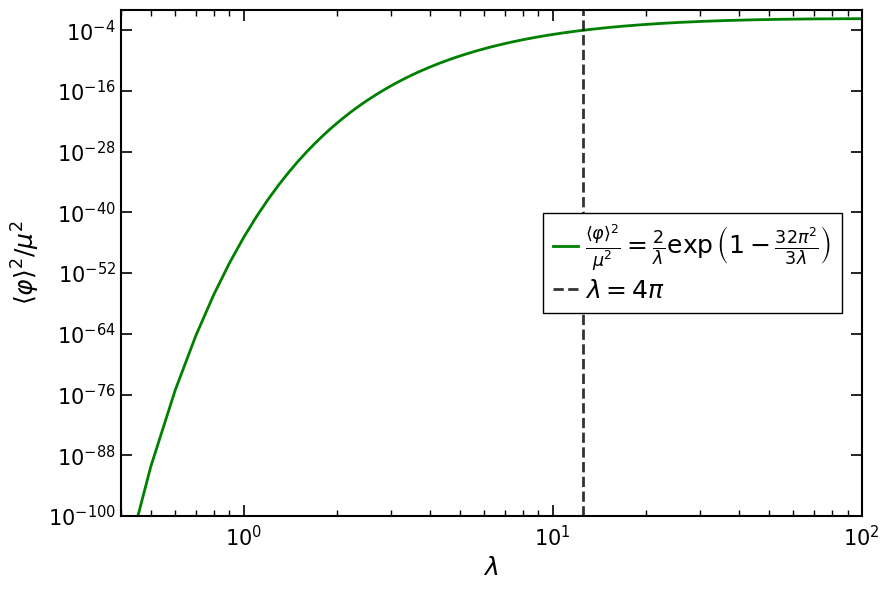

In [99]:
l = np.linspace(1e-5, 100 ,1000)
y = 2/l * np.exp(1-(32*np.pi**2)/(3*l))

fig, ax = plt.subplots(figsize=(9, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(l, y, label=r'$\frac{\langle\varphi\rangle^2}{\mu^2}=\frac{2}{\lambda}\exp\left({1-\frac{32\pi^2}{3\lambda}}\right)$', color='g', lw=2, ls='-')
ax.axvline(4*np.pi, label=r'$ \lambda =4 \pi$', color='k', lw=2, ls='--', alpha=0.8)

ax.set_xlim(4e-1, 100)
ax.set_ylim(1e-100, 1)

ax.set_xlabel(r'$\lambda$', fontsize=18)
ax.set_ylabel(r'$\langle\varphi\rangle^2/\mu^2$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='x', scilimits=(-2, 2))
ax.xaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.set_yscale('log')
ax.set_xscale('log')

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "center right", bbox_to_anchor=(0.99, 0.5),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"RSF_Veff_RSB_VEV.pdf", format="pdf", bbox_inches="tight")
plt.show()